In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [2]:
# Variables globales

########densité
rho_A = 1050   #(en kg/m^3)
rho_E = 1050
rho_L = 1025

######viscosité

mu_A = 0.25 #(en Pa.s)
mu_E = 0.75
mu_L = 1e-3

#######tensor viscoelastic coefficient
#gamma_A = 1.2e-9 #(en kg/(m*day))
#gamma_E = 1.2e-9

gamma_A = 1.2e-9/(24*1e6) #(en kg/(micro-mètres*heures))
gamma_E = 1.2e-9/(24*1e6)

#######tenseur viscoelastic exponent
beta_A = 1.
beta_E = 1.

#######friction coefficient
#friction_A_E = 20 #(en kg/(m^3*day))
#friction_E_L = 20
#friction_A_L = 20

friction_A_E = 20./(24*(1e6)**3) #(en kg/(m^3*heures))
friction_E_L = 20./(24*(1e6)**3)
friction_A_L = 20./(24*(1e6)**3)

######growth, excretion and degradation rate
#mu_growth = 2.  #( en 1/jour)
#mu_excretion = 0.4
#mu_death = 0.2

#en heures:
mu_growth = 2./24
mu_excretion = 0.4/24.
mu_death = 0.2/24.

######pseudo-stochiometric coefficients
eta_A = 1.
eta_S = 8.67e-2
eta_L = 0.96
eta_E = 0.90

########## close packing thresold
phi_A_star = 0.75
phi_E_star = 0.75

In [3]:
def calcul_tenseur_elastic(phi_alpha, gamma_alpha, beta_alpha, phi_alpha_star):
    return gamma_alpha*(phi_alpha/phi_alpha_star)**beta_alpha

# def calcul_tenseur_contrainte_visc(phi_alpha, dv_dx, mu_alpha):
#     return (4/3)*mu_alpha*phi_alpha*dv_dx

def calcul_force_friction_A(v_A, v_E, v_L):
    return friction_A_E*(v_E-v_A) + friction_A_L*(v_L-v_A)

def calcul_force_friction_E(v_A, v_E, v_L):
    return friction_A_E*(v_A-v_E) + friction_E_L*(v_L-v_E)

def calcul_force_friction_L(v_A, v_E, v_L):
    return friction_A_L*(v_A-v_L) + friction_E_L*(v_E-v_L)

def calcul_echange_masse(phi_A, phi_L):
    #s'assurer que les fractions volumiques sont positives (#Nouveau)
    phi_A_phys = np.maximum(phi_A, 0.)
    phi_L_phys = np.maximum(phi_L, 0.)
##
    psi_growth = mu_growth*rho_A*phi_A_phys*phi_L_phys
    psi_excretion = mu_excretion*rho_A*phi_A_phys
    psi_death = mu_death*rho_A*phi_A_phys

    Gamma_A = psi_growth - psi_excretion - psi_death
    Gamma_E = psi_excretion + eta_E*psi_death
    Gamma_L = (1-eta_E)*psi_death - eta_L*psi_growth

    return Gamma_A, Gamma_E, Gamma_L

In [4]:
def solve_pp(vA_star, vE_star, vL_star, phiA_new_face, phiE_new_face, phiL_new_face, GammaA, GammaE, GammaL, dx, dt):

    N = len(vA_star)-1
    A = np.zeros((N, N))
    b = np.zeros(N)

    coef = 1./dx**2

    sum_phi = phiA_new_face/rho_A + phiE_new_face/rho_E + phiL_new_face/rho_L # taille N+1
    echange_mass = GammaA/rho_A + GammaE/rho_E + GammaL/rho_L #taille N (calculé au centre des cellules)

    sum_phiv = phiA_new_face*vA_star + phiE_new_face*vE_star + phiL_new_face*vL_star

    for i in range(1, N-1):
        A[i,i] = -coef*(sum_phi[i]+sum_phi[i+1])
        if i>0:
            A[i,i-1] = coef*sum_phi[i]
        if i<N-1:
            A[i,i+1] = coef*sum_phi[i+1]


# Condition de Neumann aux bords pour la pression
    A[0,0] = -coef*sum_phi[1]
    A[0, 1] = coef*sum_phi[1]
    A[N-1,N-1] = -coef*sum_phi[N-1]
    A[N-1, N-2] = coef*sum_phi[N-1]

    for i in range(N):
        b[i] = (1./dt)*((sum_phiv[i+1] - sum_phiv[i])/dx - echange_mass[i])

#Gestion de la singularité de la matrice A (non-inversible): On va fixer la pression p1 = 0
#Donc la première ligne de A sera [1, 0, ..., 0] et la première composante de b sera 0


    A[0, :] = 0.
    A[0, 0] = coef
    b[0] = 0.


    p = np.linalg.solve(A, b)
    return p

In [5]:
def solve_biofilm(xv, xp, v0A, v0E, v0L, phi0A, phi0E, phi0L, dt_init, T, save_path=None, save_every=1000):

    Nv = len(xv)
    Np = len(xp)
    dx = xv[1]-xv[0]

    vA = np.copy(v0A)
    vE = np.copy(v0E)
    vL = np.copy(v0L)

    phiA = np.copy(phi0A)
    phiE = np.copy(phi0E)
    phiL = np.copy(phi0L)


    t = 0
    k = 0


    #Création répertoire de sauvegarde si besoin
    if save_path is not None and not os.path.exists(save_path):
        os.makedirs(save_path)
            

    while(t<T):
        #condition cfl
        vmax = np.max(np.abs(np.concatenate([vA, vE, vL]))) + 1e-10
        dt = max(min(dt_init, 0.25*dx/vmax), 1e-5) # pour éviter des pas trop petit


        ###Étape 1: Calcul de fraction volumique phi_new


        fluxA = np.zeros(Nv)#Pour les algues
        fluxE = np.zeros(Nv)#Pour la matrice extra-cellulaire
        fluxL = np.zeros(Nv)#Pour le liquide

        for i in range(Nv):
            #Pour les algues
            if vA[i]>=0:
                if i==0:
                    fluxA[i] = phiA[i]*vA[i]
                else:
                    fluxA[i] = phiA[i-1]*vA[i]
            else:
                if i==Nv-1:
                    fluxA[i] = phiA[i-1]*vA[i]
                else:
                    fluxA[i] = phiA[i]*vA[i]

            #Pour la matrice extra-cellulaire
            if vE[i]>=0:
                if i==0:
                    fluxE[i] = phiE[i]*vE[i]
                else:
                    fluxE[i] = phiE[i-1]*vE[i]
            else:
                if i==Nv-1:
                    fluxE[i] = phiE[i-1]*vE[i]
                else:
                    fluxE[i] = phiE[i]*vE[i]

            #Pour le liquide
            #if vL[i]>=0:
             #   if i==0:
                #    fluxL[i] = phiL[i]*vL[i]
             #   else:
               #     fluxL[i] = phiL[i-1]*vL[i]
          #  else:
           #     if i==Nv-1:
           #         fluxL[i] = phiL[i-1]*vL[i]
           #     else:
                #    fluxL[i] = phiL[i]*vL[i]




        GammaA, GammaE, GammaL = calcul_echange_masse(phiA, phiL)
        phiA_new = phiA - (dt/dx)*(fluxA[1:]-fluxA[:-1]) + (dt/rho_A)*GammaA
        phiE_new = phiE - (dt/dx)*(fluxE[1:]-fluxE[:-1]) + (dt/rho_E)*GammaE
        #phiL_new = phiL - (dt/dx)*(fluxL[1:]-fluxL[:-1]) + (dt/rho_L)*GammaL

        phiL_new = 1 - phiA_new - phiE_new # une deuxième stratégie afin de garantir la contrainte de remplissage du volume à chaque pas de temps
        #s'assurer que phi est dans [0, 1] --> des valeurs physiquement pertinentes
        # phiA_new = np.maximum(phiA_new, 0.)
        # phiA_new = np.minimum(phiA_new, 1.)
        # phiE_new = np.maximum(phiE_new, 0.)
        # phiE_new = np.minimum(phiE_new, 1.)
        # phiL_new = np.maximum(phiL_new, 0.)
        # phiL_new = np.minimum(phiL_new, 1.)

        ###Étape 2: Calcul de vitesse intermédiaire v*


        #interpolation de phi sur les points de vitesse
        phiA_face = np.zeros(Nv)
        phiA_face[1:-1] = 0.5*(phiA[1:] + phiA[:-1])
        phiA_face[0] = phiA[0]
        phiA_face[-1]= phiA[-1]

        phiE_face = np.zeros(Nv)
        phiE_face[1:-1] = 0.5*(phiE[1:] + phiE[:-1])
        phiE_face[0] = phiE[0]
        phiE_face[-1]= phiE[-1]

        phiL_face = np.zeros(Nv)
        phiL_face[1:-1] = 0.5*(phiL[1:] + phiL[:-1])
        phiL_face[0] = phiL[0]
        phiL_face[-1]= phiL[-1]

        #interpolation de phi_new sur les points de vitesse (des nouveaux phi précédemment calculés)
        phiA_new_face = np.zeros(Nv)
        phiA_new_face[1:-1] = 0.5*(phiA_new[1:] + phiA_new[:-1])
        phiA_new_face[0] = phiA_new[0]
        phiA_new_face[-1]= phiA_new[-1]

        phiE_new_face = np.zeros(Nv)
        phiE_new_face[1:-1] = 0.5*(phiE_new[1:] + phiE_new[:-1])
        phiE_new_face[0] = phiE_new[0]
        phiE_new_face[-1]= phiE_new[-1]

        phiL_new_face = np.zeros(Nv)
        phiL_new_face[1:-1] = 0.5*(phiL_new[1:] + phiL_new[:-1])
        phiL_new_face[0] = phiL_new[0]
        phiL_new_face[-1]= phiL_new[-1]


        #calcul du flux issue de l'équation de conservation de quantité de mouvement : gA, gE et gL
        #
        gA = np.zeros(Nv+1) # on ajoute deux points fantômes
        gE = np.zeros(Nv+1)
        gL = np.zeros(Nv+1)

        for i in range(1, Nv): #(flux internes calculer sur les points de pression)
            #Pour les algues
            if 0.5*(vA[i-1]+vA[i]) >=0:
                gA[i] = phiA[i-1]*(vA[i-1])**2
            else:
                gA[i] = phiA[i-1]*(vA[i]**2)


            #Pour la matrice extra-cellulaire
            if 0.5*(vE[i-1]+vE[i]) >=0:
                gE[i] = phiE[i-1]*(vE[i-1])**2
            else:
                gE[i] = phiE[i-1]*(vE[i]**2)

            #Pour le liquide
            if 0.5*(vL[i-1]+vL[i]) >=0:
                gL[i] = phiL[i-1]*(vL[i-1])**2
            else:
                gL[i] = phiL[i-1]*(vL[i]**2)

        #on pose que le flux dans la cellule fantôme de gauche est égal à celui de la première cellule, idem pour la cellule fantôme de droite
        gA[0] = gA[1]
        gA[-1] = gA[-2]

        gE[0] = gE[1]
        gE[-1] = gE[-2]

        gL[0] = gL[1]
        gL[-1] = gL[-2]


        GammaA_face, GammaE_face, GammaL_face = calcul_echange_masse(phiA_face, phiL_face)
        ForceA = calcul_force_friction_A(vA, vE, vL)
        ForceE = calcul_force_friction_E(vA, vE, vL)
        ForceL = calcul_force_friction_L(vA, vE, vL)

        piA = calcul_tenseur_elastic(phiA_face, gamma_A, beta_A, phi_A_star)
        piE = calcul_tenseur_elastic(phiE_face, gamma_E, beta_E, phi_E_star)

        vA_star = np.copy(vA)
        vE_star = np.copy(vE)
        vL_star = np.copy(vL)
        for i in range(1, Nv-1):
            vA_star[i] = (1./(phiA_new_face[i]+1e-10)) * (phiA_face[i]*vA[i] - (dt/dx)*(gA[i]-gA[i-1]) -(dt/(rho_A*dx))*(piA[i]-piA[i-1]) +(dt/rho_A)*(ForceA[i] + GammaA_face[i]*vA[i])) if phiA_new_face[i]>1e-5 else 0.
            vE_star[i] = (1./(phiE_new_face[i]+1e-10)) * (phiE_face[i]*vE[i] - (dt/dx)*(gE[i]-gE[i-1]) -(dt/(rho_E*dx))*(piE[i]-piE[i-1]) +(dt/rho_E)*(ForceE[i] + GammaE_face[i]*vE[i])) if phiE_new_face[i]>1e-5 else 0.
            vL_star[i] = (1./(phiL_new_face[i]+1e-10)) * (phiL_face[i]*vL[i] - (dt/dx)*(gL[i]-gL[i-1]) +(dt/rho_L)*(ForceL[i] + GammaL_face[i]*vL[i])) if phiL_new_face[i]>1e-5 else 0.


        #Application des conditions de bords
        vA_star[0] = 0.
        vE_star[0] = 0.
        vL_star[0] = 0.

        integrand1 = (GammaA/rho_A) + (GammaE/rho_E) + (GammaL/rho_L)
        integral1 = np.sum(integrand1)*dx
        vA_star[-1] = integral1 #Cette condition impose que le flux total au bord soit égal au bilan de production/consommation
        vE_star[-1] = integral1
        vL_star[-1] = integral1

        ###Étape 3: Résolution de l'équation de Poisson pour la pression
        p_corr = solve_pp(vA_star, vE_star, vL_star, phiA_new_face, phiE_new_face, phiL_new_face, GammaA, GammaE, GammaL, dx, dt)

        #Étape 4: Correction de la vitesse

        vA_new = np.copy(vA_star)
        vE_new = np.copy(vE_star)
        vL_new = np.copy(vL_star)
        for i in range(1, Nv-1):
            dp_dx = (p_corr[i]-p_corr[i-1])/dx
            vA_new[i] = vA_star[i] - (dt/rho_A)*dp_dx
            vE_new[i] = vE_star[i] - (dt/rho_E)*dp_dx
            vL_new[i] = vL_star[i] - (dt/rho_L)*dp_dx


        #conditions aux bords
        vA_new[0] = 0.
        vA_new[-1] = integral1

        vE_new[0] = 0.
        vE_new[-1] = integral1

        vL_new[0] = 0.
        vL_new[-1] = integral1


        vA = vA_new
        vE = vE_new
        vL = vL_new

        # ÉVITER QUE LA VITESSE EXPLOSE
        #vA = np.clip(vA_new, 0, 1e-3)      # Algues, pas de rétro-mouvement physique
        #vE = np.clip(vE_new, 0, 1e-3)      # EPS, idem
        #vL = np.clip(vL_new, -1e-2, 1e-2)  # Liquide, bornes plus larges (peut être négatif)

        phiA = phiA_new
        phiE = phiE_new
        phiL = phiL_new

        t+=dt
        k+=1

        # Sauvegarde périodique
        if save_path is not None and (k % save_every == 0 or t+dt >= T):
            np.savez(os.path.join(save_path, f"biofilm_t{t:.2f}.npz"),
                     t=t, xv = xv, xp=xp, phiA=phiA, phiE=phiE, phiL=phiL,
                     vA=vA, vE=vE, vL=vL)
                    

    print(f"Nb. iter = {k}")


    return vA, vE, vL, phiA, phiE, phiL

In [6]:
def initial_phi_A(x, H=2, L_front=0.5, epsilon=0.):
    fct = 0.5 * (1 - np.tanh((x - H)/L_front)) / 2
    return np.maximum(fct, epsilon)

def initial_phi_E(x, H=2, L_front=0.5, epsilon=0.):
    fct = 0.3 * (1 - np.tanh((x - H)/L_front)) / 2
    return np.maximum(fct, epsilon)

def initial_phi_L(x, H=2, L_front=0.5, epsilon=0.):
    # Ici, on s'assure que la somme ne dépasse pas 1 et qu'il y a un plancher minimal
    phi_A = initial_phi_A(x, H, L_front, epsilon)
    phi_E = initial_phi_E(x, H, L_front, epsilon)
    fct = 1 - phi_A - phi_E
    return np.maximum(fct, epsilon)

In [7]:
def plot_all_results(result_dir):
    files = sorted(glob.glob(f"{result_dir}/biofilm_t*.npz"),
                   key=lambda x: float(x.split("t")[-1][:-4]))
    for file in files:
        data = np.load(file)
        xp = data["xp"]
        phiA = data["phiA"]
        phiE = data["phiE"]
        phiL = data["phiL"]
        t = data["t"]
        plt.figure()
        plt.plot(xp, phiA, label="Algues")
        plt.plot(xp, phiE, label="EPS")
        plt.plot(xp, phiL, label="Liquide")
        plt.title(f"Fractions volumiques à t={t:.2f} h")
        plt.xlabel("Position (μm)")
        plt.ylabel("Fraction volumique")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{result_dir}/plot_t{t:.2f}.png")
        plt.close()
    print("Plot sauvergarder dans ", result_dir)



In [10]:
def run_all_cases():
    # Paramètres et CI
    L = 10.
    N = 512
    dx = L / N
    xv = np.linspace(0., L, N+1)
    xp = np.linspace(dx/2, L-dx/2, N)
    phi0_A = initial_phi_A(xp)
    phi0_E = initial_phi_E(xp)
    phi0_L = initial_phi_L(xp)

    # Initialisation pression/vitesse/fraction volumique
    Gamma_A, Gamma_E, Gamma_L = calcul_echange_masse(phi0_A, phi0_L)
    zeros = np.zeros(N+1)
    phi0_A_face = np.concatenate(([phi0_A[0]], 0.5*(phi0_A[1:]+ phi0_A[:-1]), [phi0_A[-1]]))
    phi0_E_face = np.concatenate(([phi0_E[0]], 0.5*(phi0_E[1:]+ phi0_E[:-1]), [phi0_E[-1]]))
    phi0_L_face = np.concatenate(([phi0_L[0]], 0.5*(phi0_L[1:]+ phi0_L[:-1]), [phi0_L[-1]]))
    p = solve_pp(zeros, zeros, zeros, phi0_A_face, phi0_E_face, phi0_L_face, Gamma_A, Gamma_E, Gamma_L, 1e-2, dx)
    dp_dx = np.concatenate(([p[0]/dx],(p[1:]-p[:-1])/dx, [p[-1]/dx]))
    v0_A = -(1./rho_A)*dp_dx
    v0_E = -(1./rho_E)*dp_dx
    v0_L = -(1./rho_L)*dp_dx

    #Paramètres à tester
    T_list = [360]
    dt_list = [1e-4]

    for T in T_list:
        for dt in dt_list:
            print(f"--- Running T={T}h, dt={dt}h ---")
            save_path = f"results_T{T}_dt{dt}"
            v_A, v_E, v_L, phi_A, phi_E, phi_L = solve_biofilm(
                xv, xp, v0_A, v0_E, v0_L, phi0_A, phi0_E, phi0_L,
                dt, T, save_path=save_path, save_every=1000)

            plot_all_results(save_path)

In [11]:
run_all_cases()

--- Running T=360h, dt=0.0001h ---


LinAlgError: Singular matrix

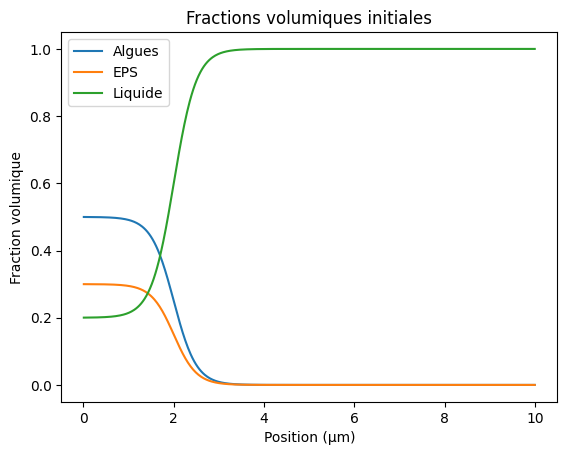

In [22]:
L = 10.
N = 512
dx = L / N
xv = np.linspace(0., L, N+1)
xp = np.linspace(dx/2, L-dx/2, N)
phi0_A = initial_phi_A(xp)
phi0_E = initial_phi_E(xp)
phi0_L = initial_phi_L(xp)

plt.plot(xp, phi0_A, label="Algues")
plt.plot(xp, phi0_E, label="EPS")
plt.plot(xp, phi0_L, label="Liquide")
plt.title(f"Fractions volumiques initiales")
plt.xlabel("Position (μm)")
plt.ylabel("Fraction volumique")
plt.legend()
plt.savefig("fractions vols init.png")
plt.show()